In [20]:
pip install pandas numpy scikit-learn xgboost catboost lightgbm shap joblib matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 7.3 MB/s eta 0:00:00


In [21]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier
import lightgbm as lgb

# Basic configuration
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [24]:
# Load data for improved model
df_improved = pd.read_csv('flood_prediction_dataset.csv')

# Check class distribution
print("Class Distribution:")
print(df_improved['is_flood'].value_counts())
print(f"\nFlood percentage: {df_improved['is_flood'].mean()*100:.2f}%")


Class Distribution:
is_flood
1    2100
0    2070
Name: count, dtype: int64

Flood percentage: 50.36%


In [25]:
# ============================================
# ADVANCED FEATURE ENGINEERING
# ============================================

# Create a copy for feature engineering
df_fe = df_improved.copy()

# 1. Encode categorical features properly
if 'season' in df_fe.columns:
    season_map = {'Spring': 1, 'Summer': 2, 'Autumn': 3, 'Winter': 4}
    df_fe['season_encoded'] = df_fe['season'].map(season_map).fillna(0)

# 2. Create interaction features (important for flood prediction)
df_fe['precipitation_temp_interaction'] = df_fe['precipitation_sum'] * df_fe['temperature_mean']
df_fe['precipitation_hours_intensity'] = df_fe['precipitation_sum'] / (df_fe['precipitation_hours'] + 1)  # Avoid division by zero
df_fe['rain_intensity'] = df_fe['rain_sum'] / (df_fe['precipitation_hours'] + 1)
df_fe['precipitation_evap_ratio'] = df_fe['precipitation_sum'] / (df_fe['evapotranspiration'] + 0.1)
df_fe['cumulative_precip_ratio'] = df_fe['precipitation_cumsum_7day'] / (df_fe['precipitation_sum'] + 0.1)

# 3. Create polynomial features for key variables
df_fe['precipitation_sum_squared'] = df_fe['precipitation_sum'] ** 2
df_fe['precipitation_cumsum_squared'] = df_fe['precipitation_cumsum_7day'] ** 2
df_fe['temp_range_squared'] = df_fe['temp_range'] ** 2

# 4. Create temporal features
df_fe['is_monsoon_season'] = df_fe['month'].isin([6, 7, 8, 9]).astype(int)
df_fe['is_peak_rainy'] = ((df_fe['month'] >= 7) & (df_fe['month'] <= 9)).astype(int)

# 5. Create weather severity indicators
df_fe['extreme_precipitation'] = (df_fe['precipitation_sum'] > df_fe['precipitation_sum'].quantile(0.9)).astype(int)
df_fe['extreme_rain'] = (df_fe['rain_sum'] > df_fe['rain_sum'].quantile(0.9)).astype(int)
df_fe['high_cumulative_precip'] = (df_fe['precipitation_cumsum_7day'] > df_fe['precipitation_cumsum_7day'].quantile(0.9)).astype(int)

# 6. Create location-based features (if multiple locations)
if 'location' in df_fe.columns:
    location_counts = df_fe['location'].value_counts()
    df_fe['location_flood_rate'] = df_fe.groupby('location')['is_flood'].transform('mean')

print(f"✅ Feature engineering complete. New shape: {df_fe.shape}")
print(f"New features created: {df_fe.shape[1] - df_improved.shape[1]}")


✅ Feature engineering complete. New shape: (4170, 46)
New features created: 15


In [26]:
# ============================================
# FEATURE SELECTION - Identify Most Important Features
# ============================================

# Select numeric features
numeric_cols = df_fe.select_dtypes(include=[np.number]).columns.tolist()
target_col = 'is_flood'

# Remove target and non-predictive features
features_to_remove = [target_col, 'flood_year', 'flood_month']  # These are leaky features
X_fe = df_fe[numeric_cols].drop(columns=[col for col in features_to_remove if col in numeric_cols], errors='ignore')
y_fe = df_fe[target_col]

print(f"Total features available: {X_fe.shape[1]}")

# 1. Feature importance using Random Forest (quick baseline)
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_selector.fit(X_fe, y_fe)

# Get feature importance
feature_importance = pd.DataFrame({
    'feature': X_fe.columns,
    'importance': rf_selector.feature_importances_
}).sort_values('importance', ascending=False)

print("\n📊 Top 20 Most Important Features (Random Forest):")
print(feature_importance.head(20).to_string(index=False))

# 2. Mutual Information Score
mi_scores = mutual_info_classif(X_fe, y_fe, random_state=42)
mi_df = pd.DataFrame({
    'feature': X_fe.columns,
    'mi_score': mi_scores
}).sort_values('mi_score', ascending=False)

print("\n📊 Top 20 Features by Mutual Information:")
print(mi_df.head(20).to_string(index=False))

# 3. Correlation with target
correlations = X_fe.corrwith(y_fe).abs().sort_values(ascending=False)
print("\n📊 Top 20 Features by Correlation with Target:")
print(correlations.head(20))


Total features available: 39

📊 Top 20 Most Important Features (Random Forest):
                     feature  importance
                 day_of_year    0.090042
   temperature_mean_7day_avg    0.068611
   temperature_mean_3day_avg    0.062844
                       month    0.056577
                        year    0.050747
                         day    0.039804
precipitation_cumsum_squared    0.038938
   precipitation_cumsum_7day    0.038385
  precipitation_sum_7day_avg    0.036151
           rain_sum_7day_avg    0.035166
     cumulative_precip_ratio    0.034071
  precipitation_sum_3day_avg    0.031661
            temperature_mean    0.031089
             temperature_min    0.030302
           rain_sum_3day_avg    0.029638
          evapotranspiration    0.028613
             temperature_max    0.027238
               windspeed_max    0.026490
               windgusts_max    0.025668
                  temp_range    0.024010

📊 Top 20 Features by Mutual Information:
                 

In [29]:
# Select top features based on multiple criteria
# Combine importance scores

# Ensure feature_importance uses 'feature' as its index before combining
feature_importance_indexed = feature_importance.set_index('feature')

combined_scores = pd.DataFrame({
    'rf_importance': feature_importance_indexed['importance'],
    'mi_score': mi_df.set_index('feature')['mi_score'],
    'correlation': correlations
}).fillna(0)

# The 'feature' column is now the index of combined_scores, reset it to be a regular column
combined_scores = combined_scores.reset_index().rename(columns={'index': 'feature'})

# Normalize scores
combined_scores['rf_norm'] = (combined_scores['rf_importance'] - combined_scores['rf_importance'].min()) / (combined_scores['rf_importance'].max() - combined_scores['rf_importance'].min() + 1e-10)
combined_scores['mi_norm'] = (combined_scores['mi_score'] - combined_scores['mi_score'].min()) / (combined_scores['mi_score'].max() - combined_scores['mi_score'].min() + 1e-10)
combined_scores['corr_norm'] = (combined_scores['correlation'] - combined_scores['correlation'].min()) / (combined_scores['correlation'].max() - combined_scores['correlation'].min() + 1e-10)

# Weighted combined score
combined_scores['combined_score'] = (
    combined_scores['rf_norm'] * 0.4 +
    combined_scores['mi_norm'] * 0.4 +
    combined_scores['corr_norm'] * 0.2
)

combined_scores = combined_scores.sort_values('combined_score', ascending=False)

print("📊 Top Features by Combined Score:")
print(combined_scores.head(25).to_string(index=False))

# Select top N features (adjust N based on your needs)
N_FEATURES = 25  # You can adjust this
selected_features = combined_scores.head(N_FEATURES)['feature'].tolist()

print(f"\n✅ Selected {len(selected_features)} top features for modeling")
print(f"Selected features: {selected_features}")

# Update X with selected features
X_selected = X_fe[selected_features]

📊 Top Features by Combined Score:
                     feature  rf_importance  mi_score  correlation  rf_norm  mi_norm  corr_norm  combined_score
                 day_of_year       0.090042  0.083197     0.002974 1.000000 1.000000   0.014839        0.802968
                       month       0.056577  0.072651     0.002941 0.626620 0.873245   0.014653        0.602877
  precipitation_sum_7day_avg       0.036151  0.034072     0.110034 0.398722 0.409531   0.620681        0.447438
   precipitation_cumsum_7day       0.038385  0.029959     0.117898 0.423653 0.360094   0.665182        0.446536
   temperature_mean_7day_avg       0.068611  0.013547     0.009531 0.760890 0.162827   0.051946        0.379876
           rain_sum_7day_avg       0.035166  0.020830     0.110365 0.387739 0.250366   0.622553        0.379753
precipitation_cumsum_squared       0.038938  0.022551     0.087398 0.429820 0.271054   0.492587        0.378867
   temperature_mean_3day_avg       0.062844  0.014996     0.010946 0.6

In [30]:
# Split data
X_train_imp, X_test_imp, y_train_imp, y_test_imp = train_test_split(
    X_selected, y_fe, test_size=0.2, random_state=42, stratify=y_fe
)

# Use RobustScaler (better for outliers) instead of StandardScaler
scaler_robust = RobustScaler()
X_train_scaled_imp = scaler_robust.fit_transform(X_train_imp)
X_test_scaled_imp = scaler_robust.transform(X_test_imp)

# Save scaler
with open('scaler_improved.pkl', 'wb') as f:
    pickle.dump(scaler_robust, f)

print(f"✅ Training set: {X_train_scaled_imp.shape}, Test set: {X_test_scaled_imp.shape}")
print(f"Training flood rate: {y_train_imp.mean():.4f}, Test flood rate: {y_test_imp.mean():.4f}")


✅ Training set: (3336, 25), Test set: (834, 25)
Training flood rate: 0.5036, Test flood rate: 0.5036


In [40]:
# ============================================
# HYPERPARAMETER TUNING - XGBoost
# ============================================

# Define parameter grid for XGBoost
xgb_param_grid = {
    'n_estimators': [200, 300, 500, 800],
    'max_depth': [4, 5, 6, 7, 8],
    'learning_rate': [0.001, 0.01, 0.1, 0.15],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.2],
    'reg_alpha': [0, 0.1, 0.5],
    'reg_lambda': [1, 1.5, 2]
}

# Base XGBoost model
xgb_base = xgb.XGBClassifier(
    objective='binary:logistic',
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False,
    n_jobs=-1
)

# Randomized search with cross-validation
print("🔍 Tuning XGBoost hyperparameters...")
xgb_random = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=xgb_param_grid,
    n_iter=80,  # Number of parameter settings sampled
    cv=3,
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

xgb_random.fit(X_train_scaled_imp, y_train_imp)

print(f"\n✅ Best XGBoost parameters:")
print(xgb_random.best_params_)
print(f"Best CV score: {xgb_random.best_score_:.4f}")

# Train best model
best_xgb = xgb_random.best_estimator_
y_pred_xgb = best_xgb.predict(X_test_scaled_imp)
xgb_accuracy = accuracy_score(y_test_imp, y_pred_xgb)
xgb_f1 = f1_score(y_test_imp, y_pred_xgb)
xgb_precision = precision_score(y_test_imp, y_pred_xgb)
xgb_recall = recall_score(y_test_imp, y_pred_xgb)

print(f"\n📊 XGBoost Results:")
print(f"Accuracy: {xgb_accuracy:.4f}")
print(f"F1 Score: {xgb_f1:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall: {xgb_recall:.4f}")


🔍 Tuning XGBoost hyperparameters...
Fitting 3 folds for each of 80 candidates, totalling 240 fits

✅ Best XGBoost parameters:
{'subsample': 0.8, 'reg_lambda': 1.5, 'reg_alpha': 0, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 8, 'learning_rate': 0.001, 'gamma': 0.2, 'colsample_bytree': 0.8}
Best CV score: 0.7446

📊 XGBoost Results:
Accuracy: 0.7038
F1 Score: 0.7228
Precision: 0.6837
Recall: 0.7667


In [47]:
# ============================================
# CATBOOST MODEL (Often performs well on tabular data)
# ============================================

print("🔍 Training CatBoost model...")

# CatBoost parameter grid
catboost_param_grid = {
    'iterations': [200, 300, 500],
    'depth': [4, 5, 6, 7],
    'learning_rate': [0.001, 0.01 ,0.05, 0.1],
    'l2_leaf_reg': [1, 3, 5],
    'border_count': [32, 64, 128]
}

catboost_base = CatBoostClassifier(
    random_state=42,
    verbose=False,
    loss_function='Logloss',
    eval_metric='F1'
)

catboost_random = RandomizedSearchCV(
    estimator=catboost_base,
    param_distributions=catboost_param_grid,
    n_iter=50,
    cv=4,
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

catboost_random.fit(X_train_scaled_imp, y_train_imp)

print(f"\n✅ Best CatBoost parameters:")
print(catboost_random.best_params_)
print(f"Best CV score: {catboost_random.best_score_:.4f}")

best_catboost = catboost_random.best_estimator_
y_pred_catboost = best_catboost.predict(X_test_scaled_imp)
catboost_accuracy = accuracy_score(y_test_imp, y_pred_catboost)
catboost_f1 = f1_score(y_test_imp, y_pred_catboost)
catboost_precision = precision_score(y_test_imp, y_pred_catboost)
catboost_recall = recall_score(y_test_imp, y_pred_catboost)

print(f"\n📊 CatBoost Results:")
print(f"Accuracy: {catboost_accuracy:.4f}")
print(f"F1 Score: {catboost_f1:.4f}")
print(f"Precision: {catboost_precision:.4f}")
print(f"Recall: {catboost_recall:.4f}")


🔍 Training CatBoost model...
Fitting 4 folds for each of 50 candidates, totalling 200 fits

✅ Best CatBoost parameters:
{'learning_rate': 0.01, 'l2_leaf_reg': 1, 'iterations': 200, 'depth': 6, 'border_count': 32}
Best CV score: 0.7732

📊 CatBoost Results:
Accuracy: 0.7470
F1 Score: 0.7589
Precision: 0.7297
Recall: 0.7905


In [33]:
# ============================================
# LIGHTGBM MODEL
# ============================================

print("🔍 Training LightGBM model...")

lgbm_param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [4, 5, 6, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0],
    'min_child_samples': [10, 20, 30],
    'reg_alpha': [0, 0.1, 0.5],
    'reg_lambda': [0, 0.1, 0.5]
}

lgbm_base = lgb.LGBMClassifier(
    objective='binary',
    random_state=42,
    verbose=-1,
    n_jobs=-1
)

lgbm_random = RandomizedSearchCV(
    estimator=lgbm_base,
    param_distributions=lgbm_param_grid,
    n_iter=30,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

lgbm_random.fit(X_train_scaled_imp, y_train_imp)

print(f"\n✅ Best LightGBM parameters:")
print(lgbm_random.best_params_)
print(f"Best CV score: {lgbm_random.best_score_:.4f}")

best_lgbm = lgbm_random.best_estimator_
y_pred_lgbm = best_lgbm.predict(X_test_scaled_imp)
lgbm_accuracy = accuracy_score(y_test_imp, y_pred_lgbm)
lgbm_f1 = f1_score(y_test_imp, y_pred_lgbm)
lgbm_precision = precision_score(y_test_imp, y_pred_lgbm)
lgbm_recall = recall_score(y_test_imp, y_pred_lgbm)

print(f"\n📊 LightGBM Results:")
print(f"Accuracy: {lgbm_accuracy:.4f}")
print(f"F1 Score: {lgbm_f1:.4f}")
print(f"Precision: {lgbm_precision:.4f}")
print(f"Recall: {lgbm_recall:.4f}")


🔍 Training LightGBM model...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

✅ Best LightGBM parameters:
{'subsample': 1.0, 'reg_lambda': 0.1, 'reg_alpha': 0.5, 'n_estimators': 300, 'min_child_samples': 20, 'max_depth': 7, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
Best CV score: 0.7473

📊 LightGBM Results:
Accuracy: 0.7026
F1 Score: 0.7136
Precision: 0.6928
Recall: 0.7357


In [48]:
# ============================================
# ENSEMBLE MODEL (Voting Classifier)
# ============================================

print("🔍 Creating Ensemble Model...")

# Create voting classifier with best models
ensemble = VotingClassifier(
    estimators=[
        ('xgb', best_xgb),
        ('catboost', best_catboost),
        ('lgbm', best_lgbm)
    ],
    voting='soft'  # Use probability voting
)

ensemble.fit(X_train_scaled_imp, y_train_imp)
y_pred_ensemble = ensemble.predict(X_test_scaled_imp)

ensemble_accuracy = accuracy_score(y_test_imp, y_pred_ensemble)
ensemble_f1 = f1_score(y_test_imp, y_pred_ensemble)
ensemble_precision = precision_score(y_test_imp, y_pred_ensemble)
ensemble_recall = recall_score(y_test_imp, y_pred_ensemble)

print(f"\n📊 Ensemble Results:")
print(f"Accuracy: {ensemble_accuracy:.4f}")
print(f"F1 Score: {ensemble_f1:.4f}")
print(f"Precision: {ensemble_precision:.4f}")
print(f"Recall: {ensemble_recall:.4f}")


🔍 Creating Ensemble Model...

📊 Ensemble Results:
Accuracy: 0.7302
F1 Score: 0.7399
Precision: 0.7191
Recall: 0.7619


In [49]:
# ============================================
# MODEL COMPARISON
# ============================================

results_df = pd.DataFrame({
    'Model': ['XGBoost', 'CatBoost', 'LightGBM', 'Ensemble'],
    'Accuracy': [xgb_accuracy, catboost_accuracy, lgbm_accuracy, ensemble_accuracy],
    'F1 Score': [xgb_f1, catboost_f1, lgbm_f1, ensemble_f1],
    'Precision': [xgb_precision, catboost_precision, lgbm_precision, ensemble_precision],
    'Recall': [xgb_recall, catboost_recall, lgbm_recall, ensemble_recall]
})

print("\n" + "="*60)
print("📊 FINAL MODEL COMPARISON")
print("="*60)
print(results_df.to_string(index=False))

# Find best model
best_model_idx = results_df['Accuracy'].idxmax()
best_model_name = results_df.loc[best_model_idx, 'Model']
best_model_accuracy = results_df.loc[best_model_idx, 'Accuracy']

print(f"\n🏆 Best Model: {best_model_name} with Accuracy: {best_model_accuracy:.4f}")
print(f"📈 Improvement over baseline: {(best_model_accuracy - 0.7602)*100:.2f}%")



📊 FINAL MODEL COMPARISON
   Model  Accuracy  F1 Score  Precision   Recall
 XGBoost  0.703837  0.722783   0.683652 0.766667
CatBoost  0.747002  0.758857   0.729670 0.790476
LightGBM  0.702638  0.713626   0.692825 0.735714
Ensemble  0.730216  0.739884   0.719101 0.761905

🏆 Best Model: CatBoost with Accuracy: 0.7470
📈 Improvement over baseline: -1.32%


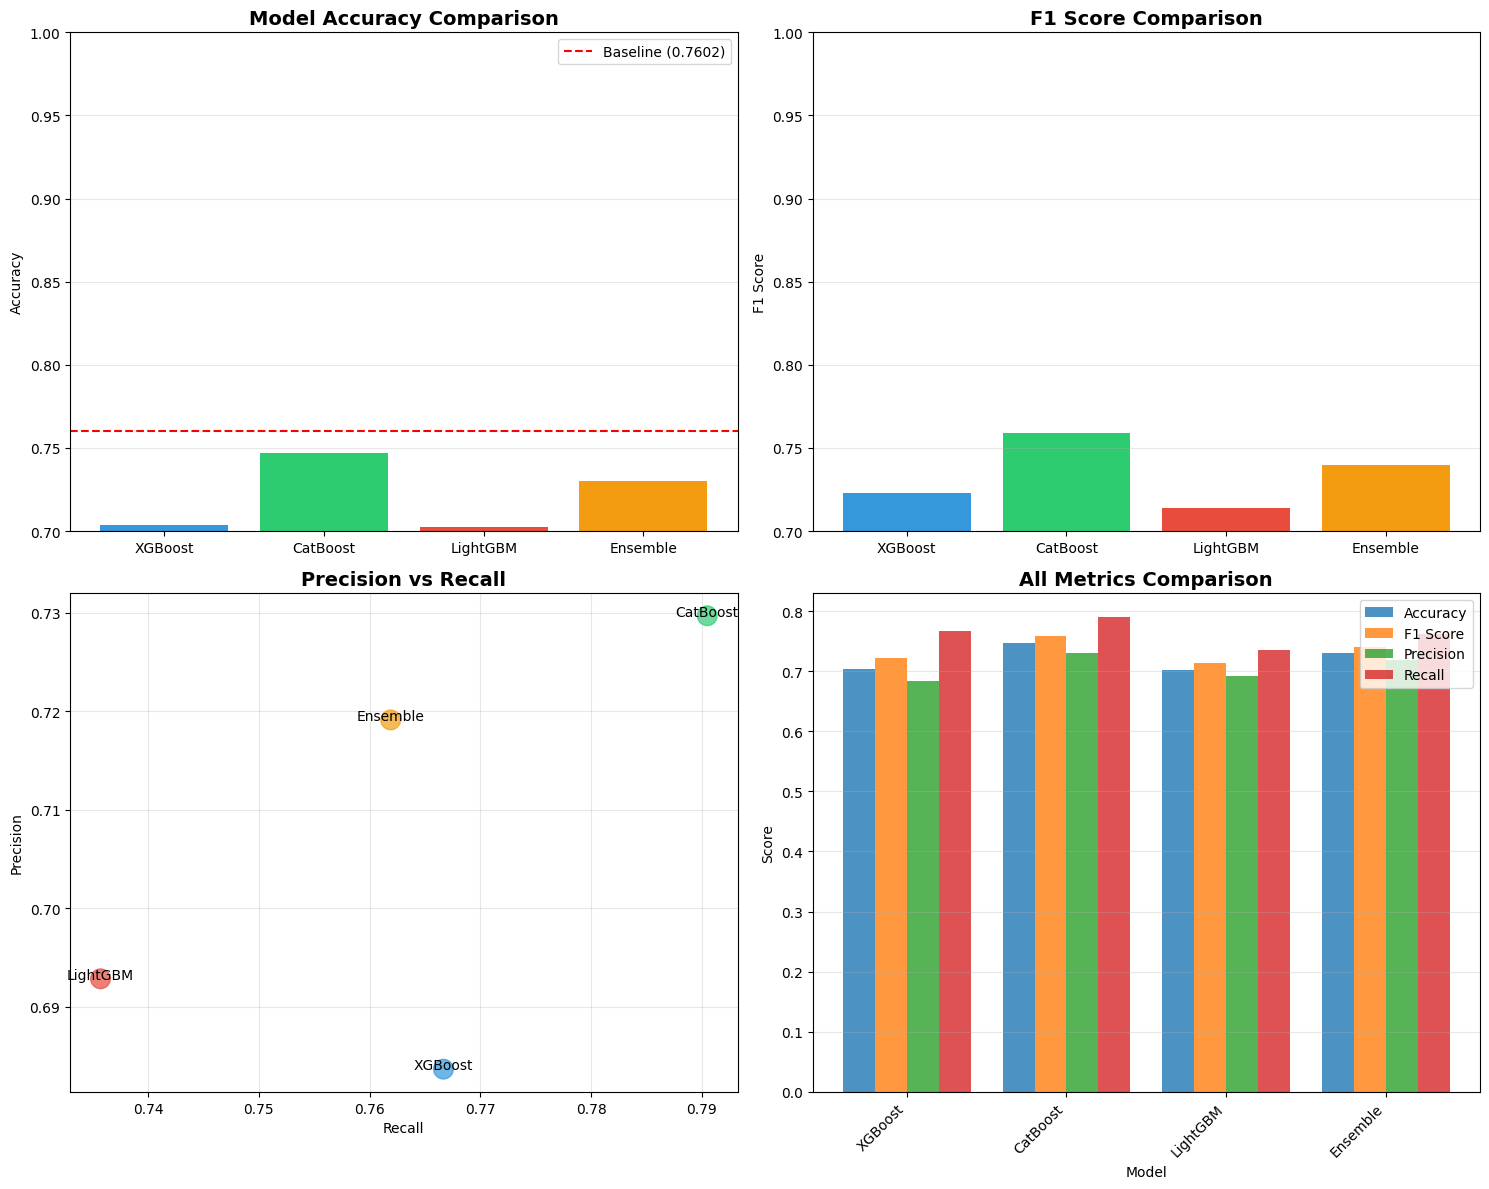

In [50]:
# ============================================
# VISUALIZATION - Model Performance Comparison
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Accuracy comparison
axes[0, 0].bar(results_df['Model'], results_df['Accuracy'], color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12'])
axes[0, 0].set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_ylim([0.7, 1.0])
axes[0, 0].axhline(y=0.7602, color='r', linestyle='--', label='Baseline (0.7602)')
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# F1 Score comparison
axes[0, 1].bar(results_df['Model'], results_df['F1 Score'], color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12'])
axes[0, 1].set_title('F1 Score Comparison', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('F1 Score')
axes[0, 1].set_ylim([0.7, 1.0])
axes[0, 1].grid(axis='y', alpha=0.3)

# Precision vs Recall
axes[1, 0].scatter(results_df['Recall'], results_df['Precision'], s=200, alpha=0.7, c=['#3498db', '#2ecc71', '#e74c3c', '#f39c12'])
for i, model in enumerate(results_df['Model']):
    axes[1, 0].annotate(model, (results_df['Recall'][i], results_df['Precision'][i]),
                        fontsize=10, ha='center')
axes[1, 0].set_xlabel('Recall')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].set_title('Precision vs Recall', fontsize=14, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# All metrics comparison
x = np.arange(len(results_df['Model']))
width = 0.2
axes[1, 1].bar(x - width*1.5, results_df['Accuracy'], width, label='Accuracy', alpha=0.8)
axes[1, 1].bar(x - width*0.5, results_df['F1 Score'], width, label='F1 Score', alpha=0.8)
axes[1, 1].bar(x + width*0.5, results_df['Precision'], width, label='Precision', alpha=0.8)
axes[1, 1].bar(x + width*1.5, results_df['Recall'], width, label='Recall', alpha=0.8)
axes[1, 1].set_xlabel('Model')
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_title('All Metrics Comparison', fontsize=14, fontweight='bold')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(results_df['Model'], rotation=45, ha='right')
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


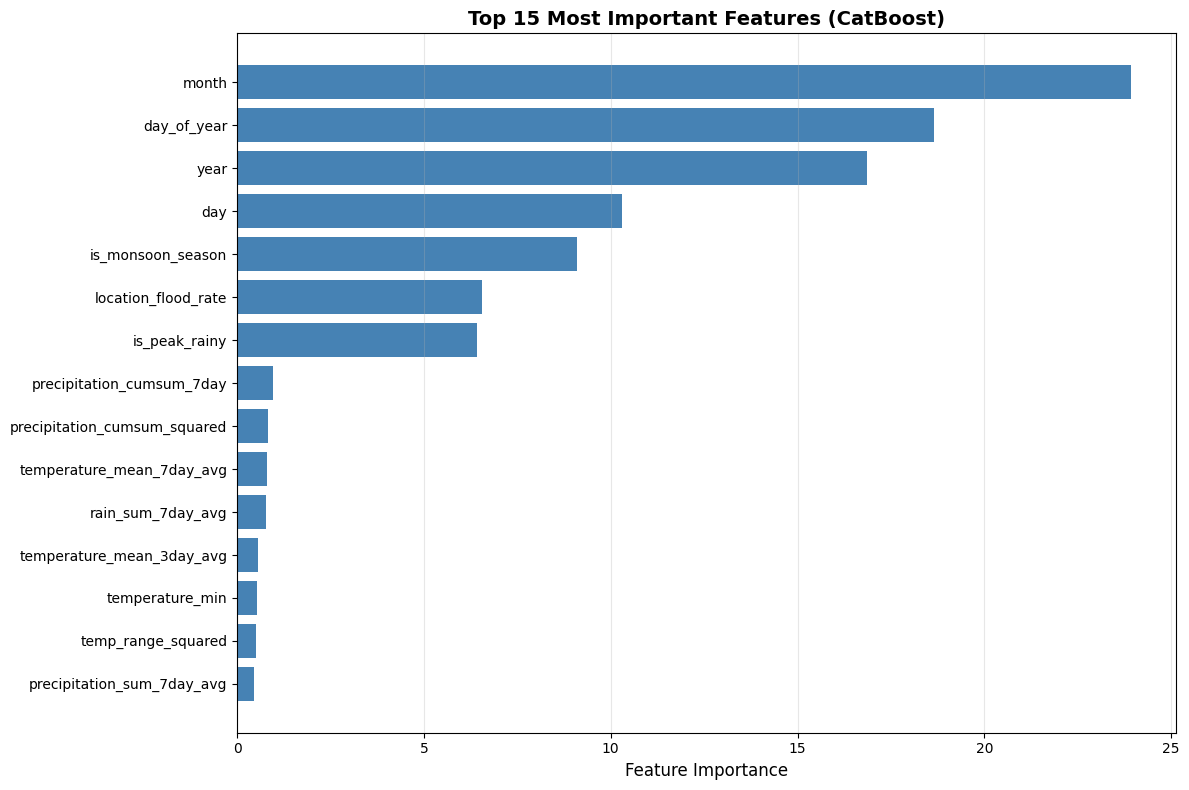


📊 Top 15 Most Important Features for Flood Prediction:
                     feature  importance
                       month   23.930894
                 day_of_year   18.663874
                        year   16.852606
                         day   10.307460
           is_monsoon_season    9.090427
         location_flood_rate    6.548551
               is_peak_rainy    6.409138
   precipitation_cumsum_7day    0.967062
precipitation_cumsum_squared    0.839975
   temperature_mean_7day_avg    0.787573
           rain_sum_7day_avg    0.762267
   temperature_mean_3day_avg    0.556746
             temperature_min    0.545074
          temp_range_squared    0.509528
  precipitation_sum_7day_avg    0.460734


In [51]:
# ============================================
# FEATURE IMPORTANCE VISUALIZATION (Best Model)
# ============================================

# Get feature importance from best model
if best_model_name == 'XGBoost':
    model_for_importance = best_xgb
elif best_model_name == 'CatBoost':
    model_for_importance = best_catboost
elif best_model_name == 'LightGBM':
    model_for_importance = best_lgbm
else:
    model_for_importance = best_xgb  # Default to XGBoost

# Get feature importance
if hasattr(model_for_importance, 'feature_importances_'):
    importances = model_for_importance.feature_importances_
    feature_names = X_selected.columns

    # Create DataFrame
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False)

    # Plot top 15 features
    plt.figure(figsize=(12, 8))
    top_features = importance_df.head(15)
    plt.barh(range(len(top_features)), top_features['importance'], color='steelblue')
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.xlabel('Feature Importance', fontsize=12)
    plt.title(f'Top 15 Most Important Features ({best_model_name})', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("\n📊 Top 15 Most Important Features for Flood Prediction:")
    print(importance_df.head(15).to_string(index=False))


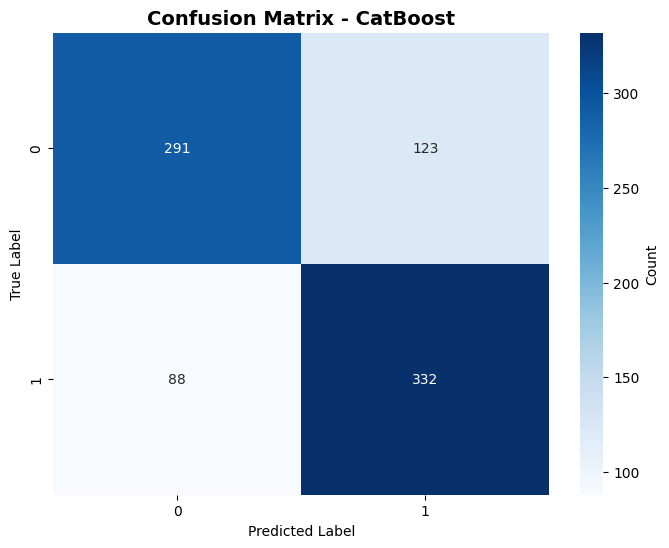


📊 Classification Report for CatBoost:
              precision    recall  f1-score   support

    No Flood       0.77      0.70      0.73       414
       Flood       0.73      0.79      0.76       420

    accuracy                           0.75       834
   macro avg       0.75      0.75      0.75       834
weighted avg       0.75      0.75      0.75       834



In [52]:
# ============================================
# CONFUSION MATRIX FOR BEST MODEL
# ============================================

# Get predictions from best model
if best_model_name == 'XGBoost':
    y_pred_best = y_pred_xgb
elif best_model_name == 'CatBoost':
    y_pred_best = y_pred_catboost
elif best_model_name == 'LightGBM':
    y_pred_best = y_pred_lgbm
else:
    y_pred_best = y_pred_ensemble

# Confusion Matrix
cm = confusion_matrix(y_test_imp, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Count'})
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Classification Report
print(f"\n📊 Classification Report for {best_model_name}:")
print(classification_report(y_test_imp, y_pred_best, target_names=['No Flood', 'Flood']))


In [53]:
# ============================================
# SAVE BEST MODEL
# ============================================

# Save the best model
if best_model_name == 'XGBoost':
    best_model = best_xgb
elif best_model_name == 'CatBoost':
    best_model = best_catboost
elif best_model_name == 'LightGBM':
    best_model = best_lgbm
else:
    best_model = ensemble

# Save model
with open('flood_prediction_model_improved.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Save feature names
with open('selected_features.pkl', 'wb') as f:
    pickle.dump(selected_features, f)

print(f"✅ Best model ({best_model_name}) saved as 'flood_prediction_model_improved.pkl'")
print(f"✅ Selected features saved as 'selected_features.pkl'")
print(f"✅ Scaler saved as 'scaler_improved.pkl'")


✅ Best model (CatBoost) saved as 'flood_prediction_model_improved.pkl'
✅ Selected features saved as 'selected_features.pkl'
✅ Scaler saved as 'scaler_improved.pkl'


In [54]:
# ============================================
# CROSS-VALIDATION FOR FINAL EVALUATION
# ============================================

print("🔍 Performing 5-fold cross-validation on best model...")

cv_scores = cross_val_score(
    best_model,
    X_train_scaled_imp,
    y_train_imp,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

print(f"\n📊 Cross-Validation Results:")
print(f"Mean Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
print(f"Individual CV scores: {cv_scores}")

# F1 Score CV
cv_f1_scores = cross_val_score(
    best_model,
    X_train_scaled_imp,
    y_train_imp,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

print(f"\nMean F1 Score: {cv_f1_scores.mean():.4f} (+/- {cv_f1_scores.std() * 2:.4f})")
print(f"Individual F1 scores: {cv_f1_scores}")


🔍 Performing 5-fold cross-validation on best model...

📊 Cross-Validation Results:
Mean Accuracy: 0.7644 (+/- 0.0344)
Individual CV scores: [0.75449102 0.75412294 0.76461769 0.75112444 0.7976012 ]

Mean F1 Score: 0.7717 (+/- 0.0318)
Individual F1 scores: [0.75449102 0.76571429 0.77667141 0.76149425 0.8       ]


In [55]:
# ============================================
# PREDICTION FUNCTION FOR NEW DATA
# ============================================

def predict_flood(input_data, model_path='flood_prediction_model_improved.pkl',
                  scaler_path='scaler_improved.pkl',
                  features_path='selected_features.pkl'):
    """
    Predict flood occurrence for new data

    Parameters:
    -----------
    input_data : dict or pd.DataFrame
        Input features for prediction

    Returns:
    --------
    prediction : int
        0 for no flood, 1 for flood
    probability : float
        Probability of flood occurrence
    """
    # Load model and scaler
    with open(model_path, 'rb') as f:
        model = pickle.load(f)
    with open(scaler_path, 'rb') as f:
        scaler = pickle.load(f)
    with open(features_path, 'rb') as f:
        selected_features = pickle.load(f)

    # Convert input to DataFrame if needed
    if isinstance(input_data, dict):
        input_df = pd.DataFrame([input_data])
    else:
        input_df = input_data.copy()

    # Feature engineering (same as training)
    # Add the same engineered features
    if 'precipitation_sum' in input_df.columns and 'temperature_mean' in input_df.columns:
        input_df['precipitation_temp_interaction'] = input_df['precipitation_sum'] * input_df['temperature_mean']

    if 'precipitation_sum' in input_df.columns and 'precipitation_hours' in input_df.columns:
        input_df['precipitation_hours_intensity'] = input_df['precipitation_sum'] / (input_df['precipitation_hours'] + 1)

    if 'rain_sum' in input_df.columns and 'precipitation_hours' in input_df.columns:
        input_df['rain_intensity'] = input_df['rain_sum'] / (input_df['precipitation_hours'] + 1)

    if 'precipitation_sum' in input_df.columns and 'evapotranspiration' in input_df.columns:
        input_df['precipitation_evap_ratio'] = input_df['precipitation_sum'] / (input_df['evapotranspiration'] + 0.1)

    if 'precipitation_cumsum_7day' in input_df.columns and 'precipitation_sum' in input_df.columns:
        input_df['cumulative_precip_ratio'] = input_df['precipitation_cumsum_7day'] / (input_df['precipitation_sum'] + 0.1)

    if 'precipitation_sum' in input_df.columns:
        input_df['precipitation_sum_squared'] = input_df['precipitation_sum'] ** 2

    if 'precipitation_cumsum_7day' in input_df.columns:
        input_df['precipitation_cumsum_squared'] = input_df['precipitation_cumsum_7day'] ** 2

    if 'temp_range' in input_df.columns:
        input_df['temp_range_squared'] = input_df['temp_range'] ** 2

    if 'month' in input_df.columns:
        input_df['is_monsoon_season'] = input_df['month'].isin([6, 7, 8, 9]).astype(int)
        input_df['is_peak_rainy'] = ((input_df['month'] >= 7) & (input_df['month'] <= 9)).astype(int)

    # Select features
    X_pred = input_df[selected_features]

    # Scale features
    X_pred_scaled = scaler.transform(X_pred)

    # Predict
    prediction = model.predict(X_pred_scaled)[0]
    probability = model.predict_proba(X_pred_scaled)[0][1]

    return prediction, probability

# Test the prediction function with sample data
print("✅ Prediction function created!")
print("\nExample usage:")
print("prediction, probability = predict_flood(your_input_data)")


✅ Prediction function created!

Example usage:
prediction, probability = predict_flood(your_input_data)


In [72]:
import random

# Create a sample input dictionary based on selected_features
# You would typically replace these with actual data from a new day
sample_input = {
    'day_of_year': random.randint(1, 365), # Example: day of year
    'month': random.randint(1, 12),       # Example: month
    'precipitation_sum_7day_avg': random.uniform(0, 50), # Example: 7-day avg precip
    'precipitation_cumsum_7day': random.uniform(0, 100), # Example: 7-day cumulative precip
    'temperature_mean_7day_avg': random.uniform(10, 35), # Example: 7-day avg temp
    'rain_sum_7day_avg': random.uniform(0, 50),        # Example: 7-day avg rain sum
    'precipitation_cumsum_squared': random.uniform(0, 10000), # Example: squared 7-day cumsum
    'temperature_mean_3day_avg': random.uniform(10, 35),  # Example: 3-day avg temp
    'cumulative_precip_ratio': random.uniform(0, 10),    # Example: cumulative precip ratio
    'is_monsoon_season': random.choice([0, 1]),         # Example: 0 or 1
    'is_peak_rainy': random.choice([0, 1]),             # Example: 0 or 1
    'precipitation_sum_3day_avg': random.uniform(0, 30), # Example: 3-day avg precip
    'rain_sum_3day_avg': random.uniform(0, 30),        # Example: 3-day avg rain sum
    'year': 2023,                                       # Example: current year
    'day': random.randint(1, 31),                       # Example: day of month
    'high_cumulative_precip': random.choice([0, 1]),   # Example: 0 or 1
    'temp_range': random.uniform(5, 20),                # Example: temperature range
    'temp_range_squared': random.uniform(25, 400),      # Example: squared temperature range
    'temperature_min': random.uniform(0, 25),           # Example: min temperature
    'temperature_mean': random.uniform(10, 35),         # Example: mean temperature
    'evapotranspiration': random.uniform(1, 10),        # Example: evapotranspiration
    'location_flood_rate': random.uniform(0, 1),        # Example: historical flood rate for location
    'windgusts_max': random.uniform(10, 50),            # Example: max wind gusts
    'windspeed_max': random.uniform(5, 30),             # Example: max wind speed
    'temperature_max': random.uniform(15, 40),          # Example: max temperature
    'precipitation_sum': random.uniform(0, 50),         # Required for FE
    'precipitation_hours': random.uniform(0, 24)        # Required for FE
}

# Ensure 'season' is not directly used, but its encoded version is created through other features
# Ensure 'evapotranspiration' and 'precipitation_sum' are present for feature engineering
# Ensure 'rain_sum' is present for feature engineering
sample_input['rain_sum'] = random.uniform(0, sample_input['precipitation_sum'])

print("Sample Input Data:")
for feature, value in sample_input.items():
    print(f"  {feature}: {value}")

# Perform prediction
prediction, probability = predict_flood(sample_input)

print(f"\nPrediction: {'Flood' if prediction == 1 else 'No Flood'}")
print(f"Probability of Flood: {probability:.4f}")

Sample Input Data:
  day_of_year: 273
  month: 12
  precipitation_sum_7day_avg: 6.699487474506494
  precipitation_cumsum_7day: 68.34572721888199
  temperature_mean_7day_avg: 33.59120793086896
  rain_sum_7day_avg: 32.89151644833531
  precipitation_cumsum_squared: 1345.4523604912483
  temperature_mean_3day_avg: 22.73455920658035
  cumulative_precip_ratio: 6.869970310506118
  is_monsoon_season: 1
  is_peak_rainy: 1
  precipitation_sum_3day_avg: 19.023721882869285
  rain_sum_3day_avg: 29.272840933207082
  year: 2023
  day: 18
  high_cumulative_precip: 1
  temp_range: 16.152801901665043
  temp_range_squared: 65.15954162219263
  temperature_min: 3.35374718776022
  temperature_mean: 12.223854734520955
  evapotranspiration: 2.1440188028228304
  location_flood_rate: 0.159667081071451
  windgusts_max: 32.090036771212866
  windspeed_max: 7.884919215783233
  temperature_max: 32.406190531067566
  precipitation_sum: 4.679718654973525
  precipitation_hours: 23.668827518008356
  rain_sum: 0.4383054307

### Scenario 1: High Flood Risk

This scenario simulates conditions often associated with a high likelihood of flooding: high precipitation over several days, during the monsoon season, in a location historically prone to floods.

In [73]:
# Scenario 1: High Flood Risk
sample_input_high_risk = {
    'day_of_year': 200, # Mid-summer
    'month': 7,         # July (monsoon season)
    'precipitation_sum_7day_avg': 40.0, # High 7-day avg precipitation
    'precipitation_cumsum_7day': 250.0, # High 7-day cumulative precipitation
    'temperature_mean_7day_avg': 28.0,  # Warm temperatures
    'rain_sum_7day_avg': 35.0,        # High 7-day avg rain sum
    'precipitation_cumsum_squared': 62500.0, # High squared cumulative precip
    'temperature_mean_3day_avg': 29.0,  # Warm 3-day avg temp
    'cumulative_precip_ratio': 5.0,     # High cumulative precip ratio
    'is_monsoon_season': 1,             # Yes, it's monsoon season
    'is_peak_rainy': 1,                 # Yes, it's peak rainy season
    'precipitation_sum_3day_avg': 30.0, # High 3-day avg precipitation
    'rain_sum_3day_avg': 25.0,        # High 3-day avg rain sum
    'year': 2023,
    'day': 19,
    'high_cumulative_precip': 1,        # High cumulative precip indicator
    'temp_range': 10.0,                 # Moderate temp range
    'temp_range_squared': 100.0,
    'temperature_min': 23.0,
    'temperature_mean': 27.0,
    'evapotranspiration': 3.0,          # Low evapotranspiration
    'location_flood_rate': 0.8,         # High historical flood rate for location
    'windgusts_max': 30.0,
    'windspeed_max': 20.0,
    'temperature_max': 32.0,
    'precipitation_sum': 50.0,          # High daily precipitation sum
    'precipitation_hours': 18.0,
    'rain_sum': 45.0
}

print("Sample Input Data (High Flood Risk):")
for feature, value in sample_input_high_risk.items():
    print(f"  {feature}: {value}")

prediction_high, probability_high = predict_flood(sample_input_high_risk)

print(f"\nPrediction: {'Flood' if prediction_high == 1 else 'No Flood'}")
print(f"Probability of Flood: {probability_high:.4f}")

Sample Input Data (High Flood Risk):
  day_of_year: 200
  month: 7
  precipitation_sum_7day_avg: 40.0
  precipitation_cumsum_7day: 250.0
  temperature_mean_7day_avg: 28.0
  rain_sum_7day_avg: 35.0
  precipitation_cumsum_squared: 62500.0
  temperature_mean_3day_avg: 29.0
  cumulative_precip_ratio: 5.0
  is_monsoon_season: 1
  is_peak_rainy: 1
  precipitation_sum_3day_avg: 30.0
  rain_sum_3day_avg: 25.0
  year: 2023
  day: 19
  high_cumulative_precip: 1
  temp_range: 10.0
  temp_range_squared: 100.0
  temperature_min: 23.0
  temperature_mean: 27.0
  evapotranspiration: 3.0
  location_flood_rate: 0.8
  windgusts_max: 30.0
  windspeed_max: 20.0
  temperature_max: 32.0
  precipitation_sum: 50.0
  precipitation_hours: 18.0
  rain_sum: 45.0

Prediction: Flood
Probability of Flood: 0.5359


### Scenario 2: Low Flood Risk

This scenario represents typical dry season conditions with minimal precipitation, outside of monsoon periods, in a location with a low historical flood rate.

In [74]:
# Scenario 2: Low Flood Risk
sample_input_low_risk = {
    'day_of_year': 30,  # Late January
    'month': 1,         # January (dry season)
    'precipitation_sum_7day_avg': 0.5, # Very low 7-day avg precipitation
    'precipitation_cumsum_7day': 3.0,  # Very low 7-day cumulative precipitation
    'temperature_mean_7day_avg': 15.0, # Cool temperatures
    'rain_sum_7day_avg': 0.2,        # Very low 7-day avg rain sum
    'precipitation_cumsum_squared': 9.0, # Low squared cumulative precip
    'temperature_mean_3day_avg': 14.0, # Cool 3-day avg temp
    'cumulative_precip_ratio': 0.1,    # Low cumulative precip ratio
    'is_monsoon_season': 0,            # No monsoon season
    'is_peak_rainy': 0,                # Not peak rainy season
    'precipitation_sum_3day_avg': 0.1, # Very low 3-day avg precipitation
    'rain_sum_3day_avg': 0.0,        # Very low 3-day avg rain sum
    'year': 2023,
    'day': 30,
    'high_cumulative_precip': 0,       # No high cumulative precip
    'temp_range': 8.0,                 # Moderate temp range
    'temp_range_squared': 64.0,
    'temperature_min': 10.0,
    'temperature_mean': 14.0,
    'evapotranspiration': 8.0,         # High evapotranspiration
    'location_flood_rate': 0.1,        # Low historical flood rate for location
    'windgusts_max': 15.0,
    'windspeed_max': 10.0,
    'temperature_max': 18.0,
    'precipitation_sum': 0.0,           # No daily precipitation
    'precipitation_hours': 0.0,
    'rain_sum': 0.0
}

print("\nSample Input Data (Low Flood Risk):")
for feature, value in sample_input_low_risk.items():
    print(f"  {feature}: {value}")

prediction_low, probability_low = predict_flood(sample_input_low_risk)

print(f"\nPrediction: {'Flood' if prediction_low == 1 else 'No Flood'}")
print(f"Probability of Flood: {probability_low:.4f}")


Sample Input Data (Low Flood Risk):
  day_of_year: 30
  month: 1
  precipitation_sum_7day_avg: 0.5
  precipitation_cumsum_7day: 3.0
  temperature_mean_7day_avg: 15.0
  rain_sum_7day_avg: 0.2
  precipitation_cumsum_squared: 9.0
  temperature_mean_3day_avg: 14.0
  cumulative_precip_ratio: 0.1
  is_monsoon_season: 0
  is_peak_rainy: 0
  precipitation_sum_3day_avg: 0.1
  rain_sum_3day_avg: 0.0
  year: 2023
  day: 30
  high_cumulative_precip: 0
  temp_range: 8.0
  temp_range_squared: 64.0
  temperature_min: 10.0
  temperature_mean: 14.0
  evapotranspiration: 8.0
  location_flood_rate: 0.1
  windgusts_max: 15.0
  windspeed_max: 10.0
  temperature_max: 18.0
  precipitation_sum: 0.0
  precipitation_hours: 0.0
  rain_sum: 0.0

Prediction: No Flood
Probability of Flood: 0.1043


### Scenario 3: Moderate Flood Risk

This scenario presents mixed conditions, with some recent rainfall but not extreme, outside the typical peak rainy season, and an average historical flood rate for the location.

In [75]:
# Scenario 3: Moderate Flood Risk
sample_input_moderate_risk = {
    'day_of_year': 100, # Early April
    'month': 4,         # April
    'precipitation_sum_7day_avg': 5.0, # Moderate 7-day avg precipitation
    'precipitation_cumsum_7day': 20.0, # Moderate 7-day cumulative precipitation
    'temperature_mean_7day_avg': 20.0, # Mild temperatures
    'rain_sum_7day_avg': 3.0,        # Moderate 7-day avg rain sum
    'precipitation_cumsum_squared': 400.0, # Moderate squared cumulative precip
    'temperature_mean_3day_avg': 21.0, # Mild 3-day avg temp
    'cumulative_precip_ratio': 2.0,    # Moderate cumulative precip ratio
    'is_monsoon_season': 0,            # Not monsoon season
    'is_peak_rainy': 0,                # Not peak rainy season
    'precipitation_sum_3day_avg': 7.0, # Moderate 3-day avg precipitation
    'rain_sum_3day_avg': 5.0,        # Moderate 3-day avg rain sum
    'year': 2023,
    'day': 10,
    'high_cumulative_precip': 0,       # No high cumulative precip
    'temp_range': 12.0,                # Average temp range
    'temp_range_squared': 144.0,
    'temperature_min': 15.0,
    'temperature_mean': 20.0,
    'evapotranspiration': 5.0,         # Average evapotranspiration
    'location_flood_rate': 0.4,        # Average historical flood rate for location
    'windgusts_max': 20.0,
    'windspeed_max': 15.0,
    'temperature_max': 26.0,
    'precipitation_sum': 10.0,          # Moderate daily precipitation
    'precipitation_hours': 6.0,
    'rain_sum': 8.0
}

print("\nSample Input Data (Moderate Flood Risk):")
for feature, value in sample_input_moderate_risk.items():
    print(f"  {feature}: {value}")

prediction_moderate, probability_moderate = predict_flood(sample_input_moderate_risk)

print(f"\nPrediction: {'Flood' if prediction_moderate == 1 else 'No Flood'}")
print(f"Probability of Flood: {probability_moderate:.4f}")


Sample Input Data (Moderate Flood Risk):
  day_of_year: 100
  month: 4
  precipitation_sum_7day_avg: 5.0
  precipitation_cumsum_7day: 20.0
  temperature_mean_7day_avg: 20.0
  rain_sum_7day_avg: 3.0
  precipitation_cumsum_squared: 400.0
  temperature_mean_3day_avg: 21.0
  cumulative_precip_ratio: 2.0
  is_monsoon_season: 0
  is_peak_rainy: 0
  precipitation_sum_3day_avg: 7.0
  rain_sum_3day_avg: 5.0
  year: 2023
  day: 10
  high_cumulative_precip: 0
  temp_range: 12.0
  temp_range_squared: 144.0
  temperature_min: 15.0
  temperature_mean: 20.0
  evapotranspiration: 5.0
  location_flood_rate: 0.4
  windgusts_max: 20.0
  windspeed_max: 15.0
  temperature_max: 26.0
  precipitation_sum: 10.0
  precipitation_hours: 6.0
  rain_sum: 8.0

Prediction: No Flood
Probability of Flood: 0.1994
